# World Cup 2026 Prediction Project - Exploratory Data Analysis
**Goal:** Understand the dataset, spot patterns, and identify useful 
features for modeling.

Dataset: International Football Results (Kaggle)

## 1. Setup and Load Data

In [22]:
# Install dependencies as needed:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

# load different datasets

goalscorers_df = pd.read_csv('../data/goalscorers.csv')
results_df = pd.read_csv('../data/results.csv', parse_dates=['date'])
shootouts_df = pd.read_csv('../data/shootouts.csv')

print(f'Rows: {len(results_df):,}')
print(f'Columns: {list(results_df.columns)}')
print(f'Date range: {results_df.date.min().date()} → {results_df.date.max().date()}')
results_df.head()

Rows: 49,287
Columns: ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']
Date range: 1872-11-30 → 2026-06-27


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2. Basic Data Quality Check

In [ ]:
print('=== Shape ===')
print(results_df.shape)

print('\n=== Dtypes ===')
print(results_df.dtypes)

print('\n=== Null counts ===')
print(results_df.isnull().sum())

print('\n=== Duplicate rows ===')
print(results_df.duplicated().sum())

print('\n=== Score statistics ===')
print(results_df[['home_score', 'away_score']].describe())

=== Shape ===
(49287, 11)

=== Dtypes ===
date              str
home_team         str
away_team         str
home_score    float64
away_score    float64
tournament        str
city              str
country           str
neutral          bool
home_wins        bool
year            int32
dtype: object

=== Null counts ===
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
home_wins      0
year           0
dtype: int64

=== Duplicate rows ===
0

=== Score statistics ===
         home_score    away_score
count  49215.000000  49215.000000
mean       1.756091      1.182404
std        1.770617      1.401770
min        0.000000      0.000000
25%        1.000000      0.000000
50%        1.000000      1.000000
75%        2.000000      2.000000
max       31.000000     21.000000


In [ ]:
results_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49287 non-null  str    
 1   home_team   49287 non-null  str    
 2   away_team   49287 non-null  str    
 3   home_score  49215 non-null  float64
 4   away_score  49215 non-null  float64
 5   tournament  49287 non-null  str    
 6   city        49287 non-null  str    
 7   country     49287 non-null  str    
 8   neutral     49287 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [ ]:
# what tournaments are covered: 
results_df["tournament"].value_counts()

tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
                                        ...  
TIFOCO Tournament                           1
Copa Confraternidad                         1
Benedikt Fontana Cup                        1
ConIFA Challenger Cup                       1
South Asian Super Cup                       1
Name: count, Length: 193, dtype: int64

In [ ]:
# how often does home team win? 
results_df["home_wins"] = results_df["home_score"] > results_df["away_score"]
results_df["home_wins"].mean()

np.float64(0.489094487390184)

<Axes: xlabel='year'>

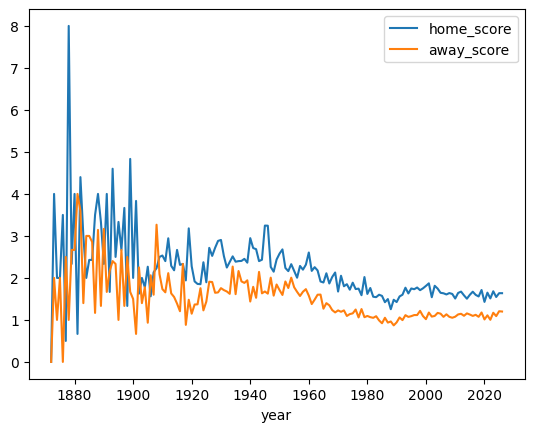

In [ ]:
# how have goal averages changed over time ? 
results_df['year'] = pd.to_datetime(results_df['date']).dt.year
results_df.groupby('year')[['home_score','away_score']].mean().plot()

In [11]:
# top nations win rates: 
top_nations = ["France", "Brazil", "Spain", "Germany", "Morocco", "Argentina", "England", "Portugal", "Netherlands", "Belgium"]
top_nation_results = results_df[results_df['home_team'].isin(top_nations) | results_df['away_team'].isin(top_nations)]
print(top_nation_results.value_counts())

date        home_team      away_team  home_score  away_score  tournament  city       country        neutral  home_wins  year
1872-11-30  Scotland       England    0.0         0.0         Friendly    Glasgow    Scotland       False    False      1872    1
1873-03-08  England        Scotland   4.0         2.0         Friendly    London     England        False    True       1873    1
1874-03-07  Scotland       England    2.0         1.0         Friendly    Glasgow    Scotland       False    True       1874    1
1875-03-06  England        Scotland   2.0         2.0         Friendly    London     England        False    False      1875    1
1876-03-04  Scotland       England    3.0         0.0         Friendly    Glasgow    Scotland       False    True       1876    1
                                                                                                                               ..
2026-03-31  Mexico         Belgium    1.0         1.0         Friendly    Chicago    United Sta

## 3. Add Derived Columns

In [ ]:
# Outcome from home team's perspective
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'home_win'
    elif row['home_score'] < row['away_score']:
        return 'away_win'
    else:
        return 'draw'

results_df['result'] = results_df.apply(get_result, axis=1)
results_df['total_goals'] = results_df['home_score'] + results_df['away_score']
results_df['goal_diff'] = results_df['home_score'] - results_df['away_score']
results_df['year'] = results_df['date'].dt.year
results_df['decade'] = (results_df['year'] // 10) * 10

print('Outcome distribution:')
print(results_df['result'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Outcome distribution:
result
home_win    48.9%
away_win    28.2%
draw        22.9%
Name: proportion, dtype: str


## 4. Tournament Coverage

=== Top 20 Tournaments by match count ===
tournament
Friendly                                18252
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64


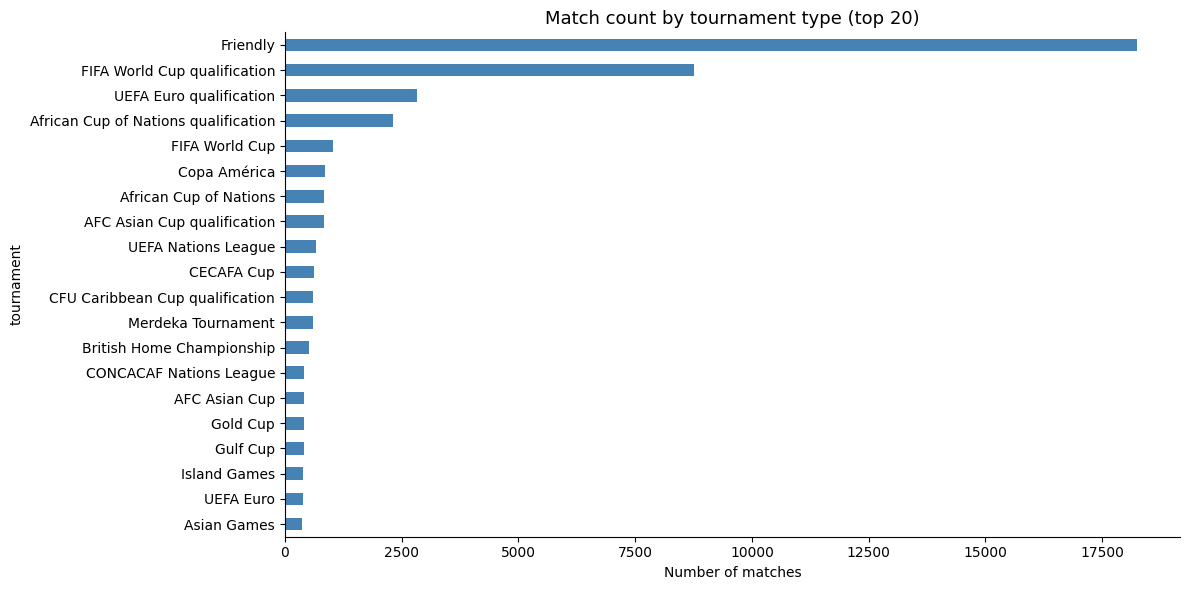

In [27]:
print('=== Top 20 Tournaments by match count ===')
top_tournaments = results_df['tournament'].value_counts().head(20)
print(top_tournaments)

fig, ax = plt.subplots(figsize=(12, 6))
top_tournaments.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of matches')
ax.set_title('Match count by tournament type (top 20)', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/plot_tournaments.png', dpi=150)
plt.show()

## 5. Home Advantage Analysis

Overall outcomes (%):
result
home_win    48.9
away_win    28.2
draw        22.9
Name: proportion, dtype: float64

Non-neutral venues — home win rate: 50.7%
Neutral venues — home win rate:     43.9%

World Cup (neutral) — home win rate: 42.4%


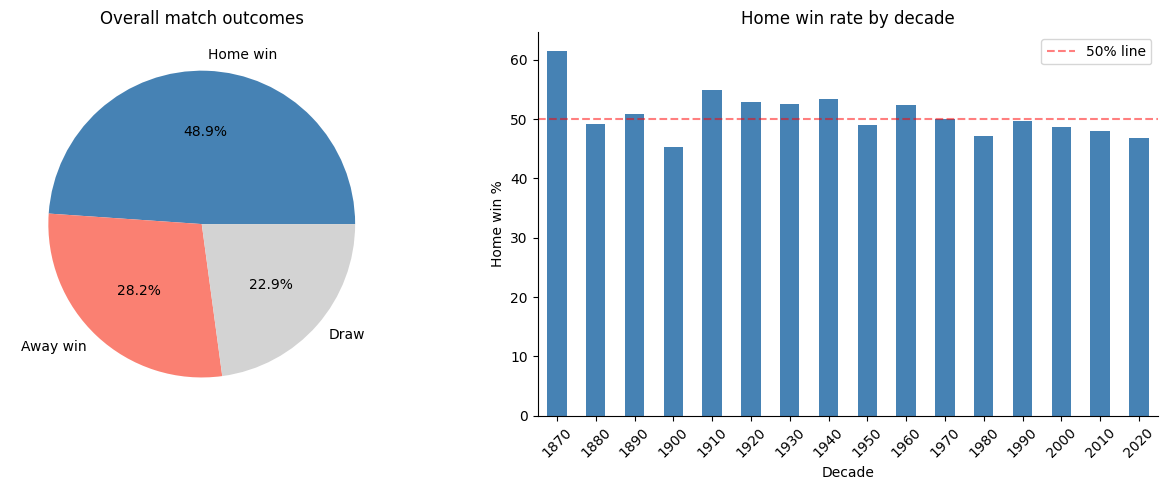

In [29]:
# Overall home advantage
result_counts = results_df['result'].value_counts(normalize=True) * 100
print('Overall outcomes (%):')
print(result_counts.round(1))

# Home advantage: neutral vs non-neutral venues
if 'neutral' in results_df.columns:
    neutral = results_df[results_df['neutral'] == True]
    non_neutral = results_df[results_df['neutral'] == False]

    print(f"\nNon-neutral venues — home win rate: {(non_neutral['result']=='home_win').mean()*100:.1f}%")
    print(f"Neutral venues — home win rate:     {(neutral['result']=='home_win').mean()*100:.1f}%")
    print(f"\nWorld Cup (neutral) — home win rate: {(results_df[results_df['tournament']=='FIFA World Cup']['result']=='home_win').mean()*100:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
result_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                   colors=['steelblue', 'salmon', 'lightgray'],
                   labels=['Home win', 'Away win', 'Draw'])
axes[0].set_title('Overall match outcomes', fontsize=12)
axes[0].set_ylabel('')

# Home win rate by decade
home_rate_by_decade = results_df.groupby('decade').apply(
    lambda x: (x['result'] == 'home_win').mean() * 100
)
home_rate_by_decade.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_xlabel('Decade')
axes[1].set_ylabel('Home win %')
axes[1].set_title('Home win rate by decade', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% line')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/plot_home_advantage.png', dpi=150)
plt.show()

## 6. Goals Analysis

=== Goals per game ===
count    49215.00
mean         2.94
std          2.09
min          0.00
25%          1.00
50%          3.00
75%          4.00
max         31.00
Name: total_goals, dtype: float64


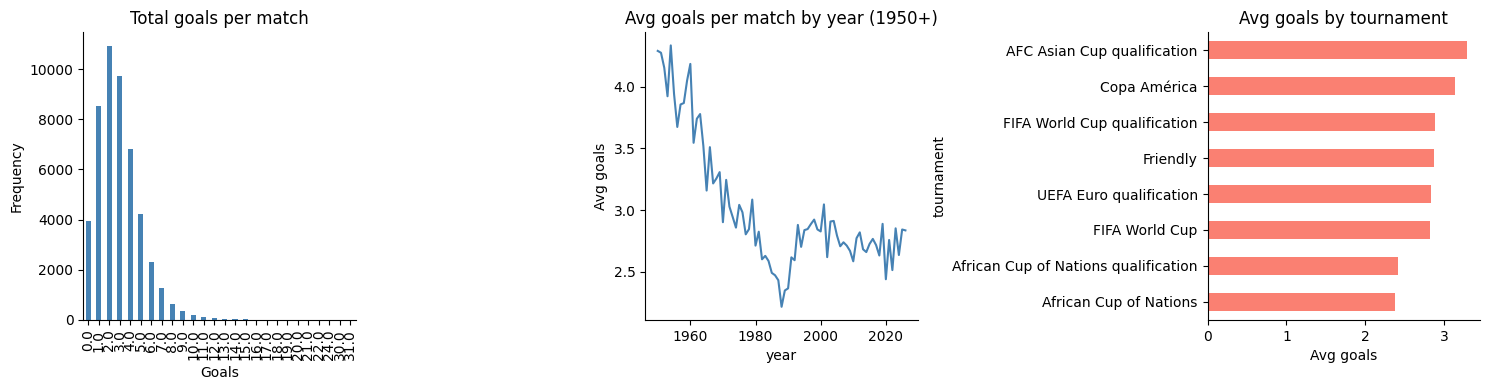

In [31]:
print('=== Goals per game ===')
print(results_df['total_goals'].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total goals distribution
results_df['total_goals'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Total goals per match', fontsize=12)
axes[0].set_xlabel('Goals')
axes[0].set_ylabel('Frequency')

# Avg goals per year (post-1950 for relevance)
modern = results_df[results_df['year'] >= 1950]
modern.groupby('year')['total_goals'].mean().plot(ax=axes[1], color='steelblue')
axes[1].set_title('Avg goals per match by year (1950+)', fontsize=12)
axes[1].set_ylabel('Avg goals')

# Goals by tournament type (top 8)
top_t = results_df['tournament'].value_counts().head(8).index
results_df[results_df['tournament'].isin(top_t)].groupby('tournament')['total_goals'].mean().sort_values().plot(
    kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Avg goals by tournament', fontsize=12)
axes[2].set_xlabel('Avg goals')

plt.tight_layout()
plt.savefig('../data/processed/plot_goals.png', dpi=150)
plt.show()



## 7. Top Nations Analysis

Top 20 teams by win rate (since 1990, min 50 games):
                played  wins  draws  losses  win_rate  points_per_game
team                                                                  
Jersey             122    83     14      25     0.680            2.156
Spain              441   291     97      53     0.660            2.200
Brazil             531   339    117      75     0.638            2.136
France             451   279    106      66     0.619            2.091
Isle of Man         58    35      4      19     0.603            1.879
Germany            482   288    108      86     0.598            2.017
Argentina          469   277    116      76     0.591            2.019
Réunion             58    34     14      10     0.586            2.000
Iran               453   262    113      78     0.578            1.985
Portugal           414   238    106      70     0.575            1.981
Netherlands        425   242    107      76     0.569            1.960
England            431  

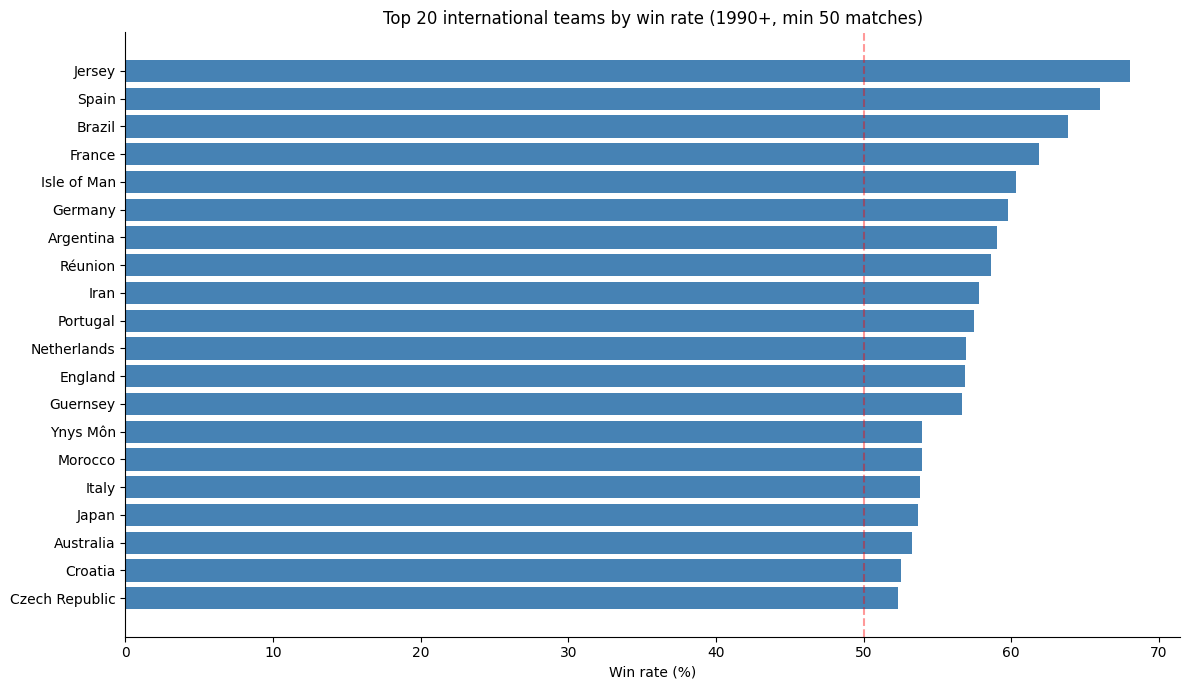


Saved team_stats.csv


In [33]:
# Compute win rate for teams with 50+ matches (post-1990)
modern = results_df[results_df['year'] >= 1990].copy()

# Home wins
home_wins = modern[modern['result'] == 'home_win'].groupby('home_team').size()
home_losses = modern[modern['result'] == 'away_win'].groupby('home_team').size()
home_draws = modern[modern['result'] == 'draw'].groupby('home_team').size()
home_played = modern.groupby('home_team').size()

# Away wins
away_wins = modern[modern['result'] == 'away_win'].groupby('away_team').size()
away_losses = modern[modern['result'] == 'home_win'].groupby('away_team').size()
away_draws = modern[modern['result'] == 'draw'].groupby('away_team').size()
away_played = modern.groupby('away_team').size()

all_teams = set(modern['home_team']).union(set(modern['away_team']))

records = []
for team in all_teams:
    w = home_wins.get(team, 0) + away_wins.get(team, 0)
    d = home_draws.get(team, 0) + away_draws.get(team, 0)
    l = home_losses.get(team, 0) + away_losses.get(team, 0)
    p = w + d + l
    if p >= 50:
        records.append({'team': team, 'played': p, 'wins': w, 'draws': d, 'losses': l,
                        'win_rate': w / p, 'points_per_game': (w * 3 + d) / p})

team_stats = pd.DataFrame(records).set_index('team').sort_values('win_rate', ascending=False)

print('Top 20 teams by win rate (since 1990, min 50 games):')
print(team_stats.head(20)[['played', 'wins', 'draws', 'losses', 'win_rate', 'points_per_game']].round(3))

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
top20 = team_stats.head(20)
bars = ax.barh(top20.index[::-1], top20['win_rate'][::-1] * 100, color='steelblue')
ax.set_xlabel('Win rate (%)')
ax.set_title('Top 20 international teams by win rate (1990+, min 50 matches)', fontsize=12)
ax.axvline(50, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../data/processed/plot_top_teams.png', dpi=150)
plt.show()

team_stats.to_csv('../data/processed/team_stats.csv')
print('\nSaved team_stats.csv')

## 8. World Cup Deep Dive

World Cup matches: 1036
WC editions: [np.int32(1930), np.int32(1934), np.int32(1938), np.int32(1950), np.int32(1954), np.int32(1958), np.int32(1962), np.int32(1966), np.int32(1970), np.int32(1974), np.int32(1978), np.int32(1982), np.int32(1986), np.int32(1990), np.int32(1994), np.int32(1998), np.int32(2002), np.int32(2006), np.int32(2010), np.int32(2014), np.int32(2018), np.int32(2022), np.int32(2026)]

WC outcome distribution:
result
home_win    42.4
away_win    30.0
draw        27.6
Name: proportion, dtype: float64

Goals by World Cup year:
      avg_goals  total_goals  matches
year                                 
1930       3.89         70.0       18
1934       4.12         70.0       17
1938       4.67         84.0       18
1950       4.00         88.0       22
1954       5.38        140.0       26
1958       3.60        126.0       35
1962       2.78         89.0       32
1966       2.78         89.0       32
1970       2.97         95.0       32
1974       2.55         97.0     

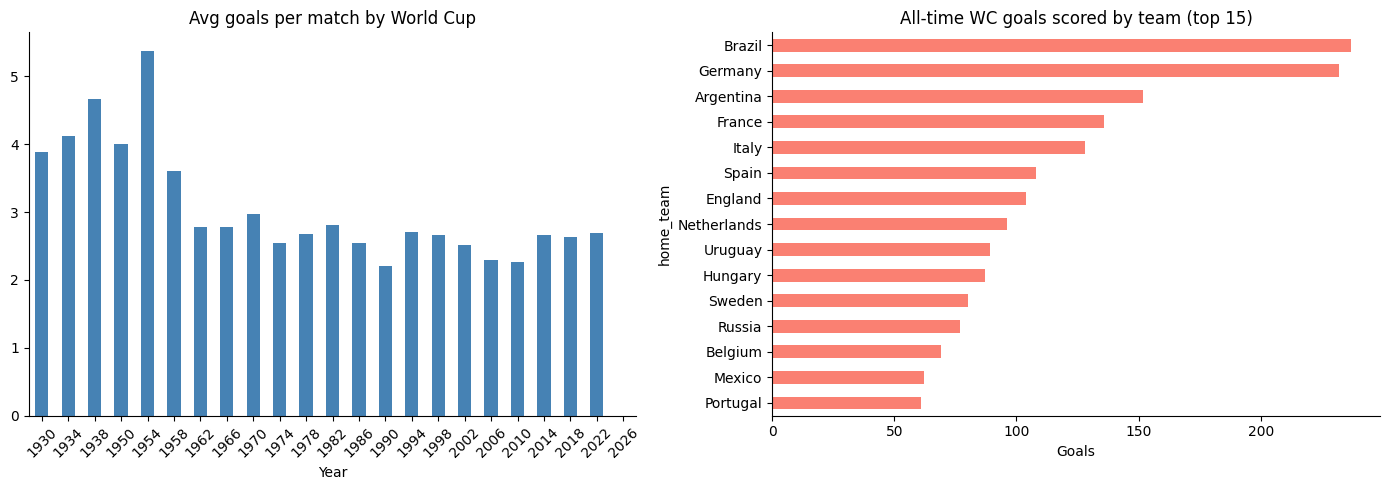

In [34]:
wc = results_df[results_df['tournament'] == 'FIFA World Cup'].copy()
print(f'World Cup matches: {len(wc)}')
print(f'WC editions: {sorted(wc["year"].unique())}')

# Outcome distribution in WC specifically
wc_outcomes = wc['result'].value_counts(normalize=True) * 100
print('\nWC outcome distribution:')
print(wc_outcomes.round(1))

# Goals per WC
wc_goals = wc.groupby('year')['total_goals'].agg(['mean', 'sum', 'count']).round(2)
wc_goals.columns = ['avg_goals', 'total_goals', 'matches']
print('\nGoals by World Cup year:')
print(wc_goals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc_goals['avg_goals'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg goals per match by World Cup', fontsize=12)
axes[0].set_xlabel('Year')
axes[0].tick_params(axis='x', rotation=45)

# Most goals scored in single WC (by team)
wc_home_goals = wc.groupby('home_team')['home_score'].sum()
wc_away_goals = wc.groupby('away_team')['away_score'].sum()
wc_team_goals = (wc_home_goals.add(wc_away_goals, fill_value=0)).sort_values(ascending=False).head(15)

wc_team_goals[::-1].plot(kind='barh', ax=axes[1], color='salmon')
axes[1].set_title('All-time WC goals scored by team (top 15)', fontsize=12)
axes[1].set_xlabel('Goals')

plt.tight_layout()
plt.savefig('../data/processed/plot_worldcup.png', dpi=150)
plt.show()

## 9. Recent Form

In [ ]:
def compute_team_recent_form(results_df, team, before_date, n=10):
    """
    Returns win rate from last n matches for a team before a given date.
    This is the function you'll use during feature engineering.
    """
    home_matches = results_df[(results_df['home_team'] == team) & (results_df['date'] < before_date)]
    away_matches = results_df[(results_df['away_team'] == team) & (results_df['date'] < before_date)]

    home_matches = home_matches.assign(win=(home_matches['result'] == 'home_win').astype(int))
    away_matches = away_matches.assign(win=(away_matches['result'] == 'away_win').astype(int))

    # Combine, sort by date, take last n
    home_part = home_matches[['date', 'win']]
    away_part = away_matches[['date', 'win']]
    all_matches = pd.concat([home_part, away_part]).sort_values('date').tail(n)

    if len(all_matches) == 0:
        return np.nan
    return all_matches['win'].mean()


# Test it on a few teams
test_date = pd.Timestamp('2022-11-01')
for team in ['Brazil', 'France', 'Germany', 'Argentina', 'England']:
    form = compute_team_recent_form(results_df, team, test_date, n=10)
    print(f"{team:<15} last-10 win rate before 2022 WC: {form:.2f}")

Brazil          last-10 win rate before 2022 WC: 0.80
France          last-10 win rate before 2022 WC: 0.50
Germany         last-10 win rate before 2022 WC: 0.40
Argentina       last-10 win rate before 2022 WC: 0.80
England         last-10 win rate before 2022 WC: 0.40


## 10. Head to Head Records

In [37]:
def head_to_head(results_df, team_a, team_b, since_year=2000):
    """
    Returns H2H stats between two teams since a given year.
    """
    mask = (
        ((results_df['home_team'] == team_a) & (results_df['away_team'] == team_b)) |
        ((results_df['home_team'] == team_b) & (results_df['away_team'] == team_a))
    ) & (results_df['year'] >= since_year)

    h2h = results_df[mask].copy()

    team_a_wins = (
        ((h2h['home_team'] == team_a) & (h2h['result'] == 'home_win')) |
        ((h2h['away_team'] == team_a) & (h2h['result'] == 'away_win'))
    ).sum()
    
    team_b_wins = (
        ((h2h['home_team'] == team_b) & (h2h['result'] == 'home_win')) |
        ((h2h['away_team'] == team_b) & (h2h['result'] == 'away_win'))
    ).sum()
    
    draws = (h2h['result'] == 'draw').sum()
    
    return {
        'matches': len(h2h),
        f'{team_a}_wins': int(team_a_wins),
        'draws': int(draws),
        f'{team_b}_wins': int(team_b_wins)
    }

# Classic rivalries
rivalries = [
    ('Brazil', 'Argentina'),
    ('Germany', 'France'),
    ('England', 'Germany'),
    ('Spain', 'Germany'),
    ('Brazil', 'Germany'),
]

for a, b in rivalries:
    stats = head_to_head(results_df, a, b)
    print(f"{a} vs {b} (since 2000): {stats}")

Brazil vs Argentina (since 2000): {'matches': 27, 'Brazil_wins': 12, 'draws': 5, 'Argentina_wins': 10}
Germany vs France (since 2000): {'matches': 15, 'Germany_wins': 4, 'draws': 3, 'France_wins': 8}
England vs Germany (since 2000): {'matches': 13, 'England_wins': 5, 'draws': 3, 'Germany_wins': 5}
Spain vs Germany (since 2000): {'matches': 10, 'Spain_wins': 5, 'draws': 3, 'Germany_wins': 2}
Brazil vs Germany (since 2000): {'matches': 6, 'Brazil_wins': 3, 'draws': 1, 'Germany_wins': 2}


In [39]:
# Filter to modern era — pre-1990 data is less useful for predicting 2026
df_modern = results_df[results_df['year'] >= 1993].copy()

print(f'Full dataset: {len(results_df):,} matches')
print(f'Modern dataset (1993+): {len(df_modern):,} matches')
print(f'Unique teams: {df_modern["home_team"].nunique()}')

df_modern.to_csv('../data/processed/results_modern.csv', index=False)
print('\nSaved results_modern.csv')


Full dataset: 49,287 matches
Modern dataset (1993+): 30,583 matches
Unique teams: 314

Saved results_modern.csv
